# Loan Default Prediction
### Binary Classification using Ensemble Learning
This notebook builds a machine learning pipeline to predict whether a loan applicant will default, using a Voting Ensemble of Random Forest and XGBoost models.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay
)

## 2. Load & Explore Data

In [2]:
df = pd.read_csv('Loan_default.csv')
print('Shape:', df.shape)
df.head()

Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['Default'].value_counts())

Missing values:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Class distribution:
Default
0    225694
1     29653
Name: count, dtype: int64


## 3. Data Preprocessing

In [4]:
# Drop ID column - no predictive value
df = df.drop('LoanID', axis=1)

# Encode binary columns
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# One-hot encode categorical columns
categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,False,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,True,False,False,False,False,False,False


## 4. Feature Engineering

In [5]:
# Create meaningful composite features
df['LoanToIncome']       = df['LoanAmount'] / (df['Income'] + 1)
df['CreditLinesPerYear'] = df['NumCreditLines'] / ((df['MonthsEmployed'] / 12) + 1)
df['RiskInteraction']    = df['InterestRate'] * df['DTIRatio']

# Drop redundant features now captured by engineered features
cols_to_drop = ['NumCreditLines', 'LoanAmount', 'MonthsEmployed']
df = df.drop(cols_to_drop, axis=1)

print('Final feature set shape:', df.shape)
df.head()

Final feature set shape: (255347, 25)


,Age,Income,CreditScore,InterestRate,LoanTerm,DTIRatio,HasMortgage,HasDependents,HasCoSigner,Default,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,LoanToIncome,CreditLinesPerYear,RiskInteraction
0,56,85994,520,15.23,36,0.44,1,1,1,0,...,False,False,False,False,False,False,True,0.588255,0.521739,6.7012
1,69,50432,458,4.81,60,0.68,0,0,1,0,...,False,True,False,False,False,False,True,2.467432,0.444444,3.2708
2,46,84208,451,21.17,24,0.31,1,1,0,1,...,True,False,False,False,False,False,False,1.534135,0.947368,6.5627
3,32,31713,743,7.07,24,0.23,0,0,0,0,...,False,True,False,True,False,False,False,1.412594,3.000000,1.6261
4,60,20437,633,6.51,48,0.73,0,1,0,0,...,True,False,False,False,False,False,False,0.447157,2.400000,4.7523


## 5. Train / Test Split

In [6]:
X = df.drop('Default', axis=1)
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (204277, 24)
Test size:  (51070, 24)


## 6. Handle Class Imbalance with SMOTE

In [7]:
# Calculate class weight ratio for XGBoost
scale = (y_train == 0).sum() / (y_train == 1).sum()
print('Scale value (used in XGBoost):', scale)

# Apply SMOTE to oversample the minority class (defaulters)
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('\nBefore SMOTE:')
print(y_train.value_counts())
print('\nAfter SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Scale value (used in XGBoost): 7.61128909872692

Before SMOTE:
Default
0    180555
1     23722
Name: count, dtype: int64

After SMOTE:
Default
0    180555
1    180555
Name: count, dtype: int64


## 7. Prepare Sample for Hyperparameter Tuning

In [8]:
# Use a subset for faster tuning
X_sample = pd.DataFrame(X_train_sm).sample(20000, random_state=42)
y_sample = pd.Series(y_train_sm).loc[X_sample.index]

## 8. Random Forest — Hyperparameter Tuning

In [9]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_dist_rf = {
    'n_estimators':      randint(100, 300),
    'max_depth':         randint(10, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10)
}

random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='recall',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_rf.fit(X_sample, y_sample)
best_rf = random_search_rf.best_estimator_
print('Best RF params:', random_search_rf.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF params: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 157}


## 9. XGBoost — Hyperparameter Tuning

In [10]:
param_dist_xgb = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(3, 10),
    'learning_rate':     uniform(0.01, 0.2),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.6, 0.4),
    'scale_pos_weight':  [scale]
}

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring='recall',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_xgb.fit(X_sample, y_sample)
best_xgb = random_search_xgb.best_estimator_
print('Best XGB params:', random_search_xgb.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGB params: {'colsample_bytree': np.float64(0.8446612641953124), 'learning_rate': np.float64(0.011413261043943482), 'max_depth': 3, 'n_estimators': 148, 'scale_pos_weight': np.float64(7.61128909872692), 'subsample': np.float64(0.8099098641033556)}


## 10. Voting Ensemble

In [11]:
voting_clf = VotingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft'
)

voting_clf.fit(X_train_sm, y_train_sm)
print('Ensemble trained successfully.')

Ensemble trained successfully.


## 11. Evaluate at Default Threshold (0.5)

In [12]:
y_pred = voting_clf.predict(X_test)
y_prob = voting_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.56      0.70     45139
           1       0.18      0.76      0.29      5931

    accuracy                           0.58     51070
   macro avg       0.56      0.66      0.50     51070
weighted avg       0.86      0.58      0.65     51070

[[25054 20085]
 [ 1437  4494]]
ROC-AUC: 0.7123273270037737


## 12. Threshold Tuning

In [13]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_custom = (y_prob >= t).astype(int)
    precision = precision_score(y_test, y_pred_custom, zero_division=0)
    recall    = recall_score(y_test, y_pred_custom)
    f1        = f1_score(y_test, y_pred_custom, zero_division=0)
    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
print(results_df.to_string())

# Select threshold: minimum recall of 0.70, maximize precision
filtered = results_df[results_df['Recall'] >= 0.70]
best_row = filtered.loc[filtered['Precision'].idxmax()]
best_threshold = best_row['Threshold']
print('\nBest Threshold:', best_threshold)

    Threshold  Precision    Recall        F1
0        0.10   0.116135  1.000000  0.208102
1        0.15   0.116135  1.000000  0.208102
2        0.20   0.116196  1.000000  0.208200
3        0.25   0.117269  0.998651  0.209890
4        0.30   0.121261  0.991738  0.216099
5        0.35   0.129453  0.971168  0.228454
6        0.40   0.142052  0.926825  0.246348
7        0.45   0.159499  0.852301  0.268711
8        0.50   0.182839  0.757714  0.294592
9        0.55   0.208197  0.621818  0.311948
10       0.60   0.236061  0.479009  0.316264
11       0.65   0.259087  0.338897  0.293666
12       0.70   0.292720  0.228461  0.256629
13       0.75   0.316150  0.132355  0.186594
14       0.80   0.349565  0.067779  0.113543
15       0.85   0.367246  0.024954  0.046732

Best Threshold: 0.5000000000000001


## 13. Final Evaluation at Best Threshold

In [14]:
y_final = (y_prob >= best_threshold).astype(int)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_final))
print('\nClassification Report:')
print(classification_report(y_test, y_final))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[25054 20085]
 [ 1437  4494]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.56      0.70     45139
           1       0.18      0.76      0.29      5931

    accuracy                           0.58     51070
   macro avg       0.56      0.66      0.50     51070
weighted avg       0.86      0.58      0.65     51070

ROC-AUC: 0.7123273270037737


## 14. Visualizations

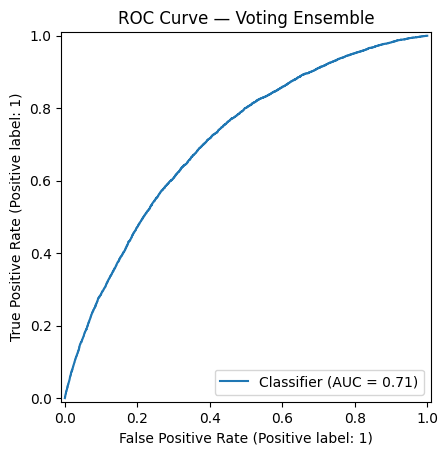

In [15]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Curve — Voting Ensemble')
plt.show()

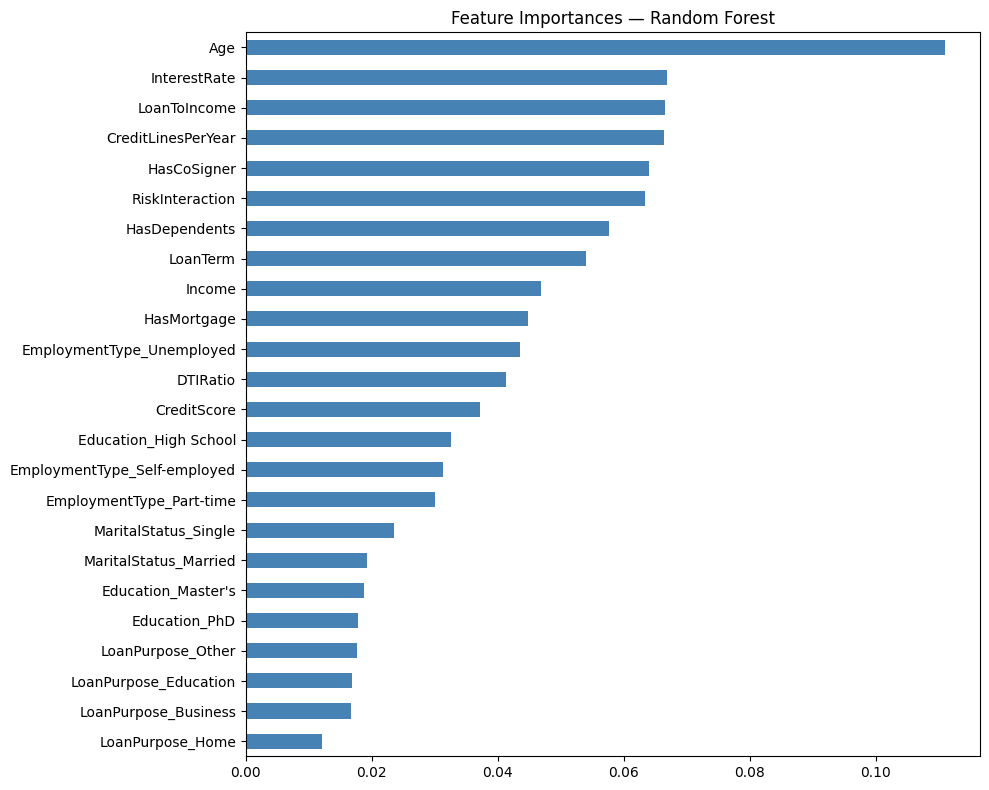

In [16]:
# Feature Importances from Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

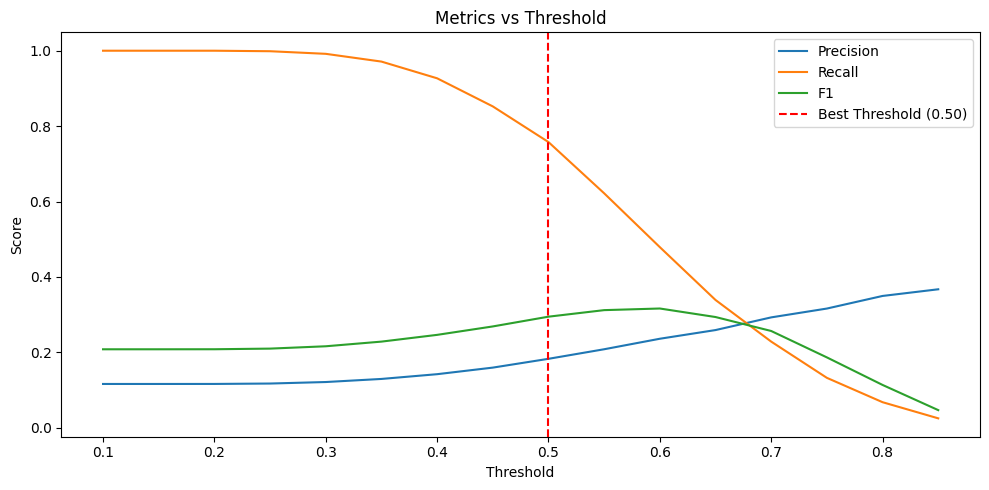

In [17]:
# Precision / Recall / F1 across thresholds
plt.figure(figsize=(10, 5))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'],    label='Recall')
plt.plot(results_df['Threshold'], results_df['F1'],        label='F1')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## 15. Save Model

In [18]:
import joblib

joblib.dump(voting_clf,    'loan_default_model.pkl')
joblib.dump(best_threshold, 'best_threshold.pkl')

print('Model saved successfully.')

Model saved successfully.


## 16. Predict on New Data

In [19]:
def predict_default(input_df):
    """
    Predicts loan default on new applicant data.
    Input must have the same features as X_train after preprocessing.
    Returns 1 (default) or 0 (no default).
    """
    prob = voting_clf.predict_proba(input_df)[:, 1]
    return (prob >= best_threshold).astype(int)